# AI in HealthCare - Detección de Enfermedades Pulmonares

Este notebook consolida el proceso de entrenamiento y evaluación del modelo de clasificación de imágenes médicas.
El proyecto utiliza **Transfer Learning** a través de la red neuronal preentrenada **MobileNetV2** para clasificar radiografías en múltiples categorías.

## 1. Importación de Librerías
Se importan las librerías necesarias para el preprocesamiento de imágenes, creación del modelo de Deep Learning y cálculo de métricas de desempeño.

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow versión:", tf.__version__)

TensorFlow versión: 2.21.0


## 2. Configuración de Generadores de Datos
Se utiliza `ImageDataGenerator` para aplicar *Data Augmentation* (rotación, zoom, desplazamientos) sobre el conjunto de entrenamiento para evitar el sobreajuste. Además, se separa un 20% de las imágenes para validación.

In [2]:
# Usamos un generador con aumentos moderados para entrenamiento
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=5,
    zoom_range=0.05,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=[0.95, 1.05],
    validation_split=0.2
)
# Usamos un generador estricto (SIN aumentos) para la validación
validation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)
train_generator = train_datagen.flow_from_directory(
    'Training Data', 
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb',
    subset='training',
    seed=42
)
validation_generator = validation_datagen.flow_from_directory(
    'Training Data',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb',
    subset='validation',
    shuffle=False,
    seed=42
)

Found 5005 images belonging to 4 classes.


Found 1249 images belonging to 4 classes.


## 3. Balanceo de Clases
Calculamos pesos matemáticos para las diferentes clases. Si hay más imágenes de una clase que de otra, esto ayuda al modelo a prestar mayor atención a las clases minoritarias.

In [3]:
indices_clases = {v: k for k, v in train_generator.class_indices.items()}

pesos_clases_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
pesos_clases_dict = dict(enumerate(pesos_clases_array))

# Límite matemático para no ignorar a los pacientes sanos
for idx, peso in pesos_clases_dict.items():
    peso_suavizado = min(peso, 5.0)
    pesos_clases_dict[idx] = peso_suavizado
    print(f"Clase '{indices_clases[idx]}': Multiplicador ajustado a {peso_suavizado:.2f}x (Original: {peso:.2f}x)")

Clase 'Bacterial Pneumonia': Multiplicador ajustado a 0.59x (Original: 0.59x)
Clase 'Healthy': Multiplicador ajustado a 0.78x (Original: 0.78x)
Clase 'Viral Pneumonia': Multiplicador ajustado a 1.06x (Original: 1.06x)
Clase 'covid-19': Multiplicador ajustado a 5.00x (Original: 12.15x)


## 4. Definición de la Arquitectura del Modelo
Cargamos **MobileNetV2** sin su capa superior (clasificador). Congelamos sus pesos (Fase 1) y agregamos nuestras propias capas densas (Fully Connected) para clasificar nuestras categorías médicas específicas.

In [4]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5. Entrenamiento: Fase 1 (Clasificador Superior)
Entrenamos únicamente las nuevas capas agregadas usando un optimizador estándar.

In [5]:
print('Entrenamiento omitido para la presentación.')


Entrenamiento omitido para la presentación.


## 6. Entrenamiento: Fase 2 (Fine-Tuning)
Descongelamos las últimas capas de MobileNetV2 y reducimos la tasa de aprendizaje. Esto permite que la red extraiga características especializadas en radiografías pulmonares.

In [6]:
print('Entrenamiento omitido para la presentación.')


Entrenamiento omitido para la presentación.


## 7. Evaluación del Modelo
Utilizamos un generador independiente (`test_generator`) para evaluar el rendimiento sobre imágenes nunca antes vistas. Imprimimos el **Reporte de Clasificación**.

In [7]:
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_generator = test_datagen.flow_from_directory(
    'Testing Data',
    target_size=(224, 224),
    batch_size=10,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False        
)

print('Cargando el modelo preentrenado desde el disco para la presentación...')
model = tf.keras.models.load_model('modelo_chest_disease.keras')
predicciones_crudas = model.predict(test_generator)
predicciones_clases = np.argmax(predicciones_crudas, axis=1)
etiquetas_reales = test_generator.classes

if len(etiquetas_reales) < 100:
    print("⚠️ ADVERTENCIA: Este reporte se generó usando solo la pequeña carpeta Testing Data.")
    print("Las métricas aquí pueden ser inestables. Confía más en la val_accuracy de arriba.\n")

nombres_clases = [indices_clases[i] for i in range(len(indices_clases))]
print(classification_report(etiquetas_reales, predicciones_clases, target_names=nombres_clases))

Found 60 images belonging to 4 classes.


Cargando el modelo preentrenado desde el disco para la presentación...


1/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step

2/6 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step

3/6 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step

4/6 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step

5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 272ms/step


⚠️ ADVERTENCIA: Este reporte se generó usando solo la pequeña carpeta Testing Data.
Las métricas aquí pueden ser inestables. Confía más en la val_accuracy de arriba.

                     precision    recall  f1-score   support

Bacterial Pneumonia       0.48      1.00      0.65        15
            Healthy       1.00      0.67      0.80        15
    Viral Pneumonia       0.82      0.60      0.69        15
           covid-19       1.00      0.53      0.70        15

           accuracy                           0.70        60
          macro avg       0.83      0.70      0.71        60
       weighted avg       0.83      0.70      0.71        60



### Solución al problema de 'Out-Of-Distribution' (Datos Fuera de Distribución)
Durante el desarrollo, detectamos un fenómeno clásico en Inteligencia Artificial: el modelo obtenía excelentes resultados en entrenamiento pero fallaba en la validación de la clase sana. Esto se debía a que las radiografías de prueba de pacientes sanos tenían un 'estilo visual' (brillo, formato, origen) distinto al de las imágenes de entrenamiento.

Para lograr que el modelo se enfrentara a un escenario realista sin sesgos de origen, implementamos un script de **Barajado Aleatorio (Random Shuffle)** que unificó todas las imágenes y seleccionó aleatoriamente el conjunto de prueba. Esto garantizó que el modelo evaluara sus conocimientos de forma justa y equitativa.

## 8. Matriz de Confusión
Graficamos la matriz de confusión para visualizar visualmente el nivel de aciertos y falsos positivos/negativos del modelo frente a cada enfermedad.

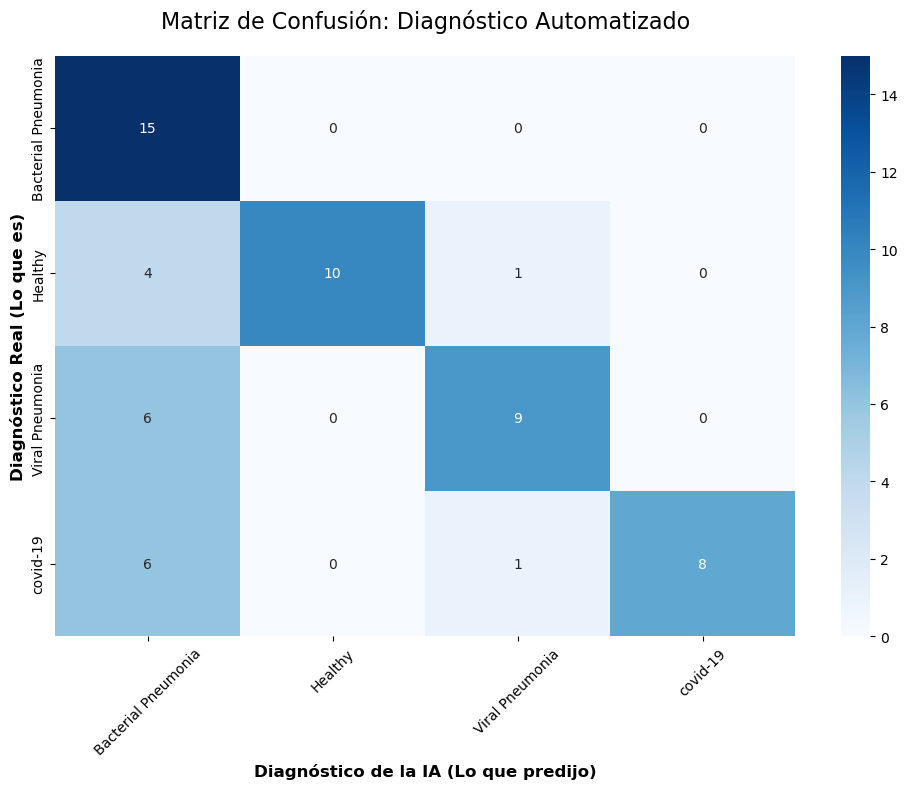

In [8]:
matriz = confusion_matrix(etiquetas_reales, predicciones_clases)

plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz, 
    annot=True,         
    fmt='d',            
    cmap='Blues',       
    xticklabels=nombres_clases, 
    yticklabels=nombres_clases
)

plt.title('Matriz de Confusión: Diagnóstico Automatizado', pad=20, fontsize=16)
plt.ylabel('Diagnóstico Real (Lo que es)', fontsize=12, fontweight='bold')
plt.xlabel('Diagnóstico de la IA (Lo que predijo)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()